In \[1\]:

    import numpy as np
    from scipy.spatial import cKDTree
    from scipy.sparse import lil_matrix, csr_matrix
    from scipy.sparse.linalg import spsolve
    import networkx as nx
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D  # noqa

    plt.rcParams.update({"font.size": 12})


    def sample_and_span(phi, r, k=2.0, L=1.0, rng=None):
        if rng is None:
            rng = np.random.default_rng()
        vol = (4.0 / 3.0) * np.pi * r ** 3
        N = int(round(phi * L ** 3 / vol))
        pts = rng.random((max(N, 1), 3)) * L
        pr = cKDTree(pts).query_pairs(r=k * 2.0 * r)
        pairs = np.array(list(pr), dtype=int).reshape(-1, 2)
        G = nx.Graph()
        G.add_nodes_from(range(len(pts)))
        G.add_edges_from(map(tuple, pairs))
        left = set(np.where(pts[:, 0] <= r)[0])
        right = set(np.where(pts[:, 0] >= L - r)[0])
        span = set()
        if left and right:
            for comp in nx.connected_components(G):
                if comp & left and comp & right:
                    span = comp
                    break
        return pts, pairs, span


    def perc_prob_3d(phi, r, k=2.0, L=1.0, trials=150, rng=None):
        if rng is None:
            rng = np.random.default_rng()
        vol = (4.0 / 3.0) * np.pi * r ** 3
        N = int(round(phi * L ** 3 / vol))
        if N < 1:
            return 0.0
        hit = 0
        for _ in range(trials):
            pts = rng.random((N, 3)) * L
            pr = cKDTree(pts).query_pairs(r=k * 2.0 * r)
            pairs = np.array(list(pr), dtype=int).reshape(-1, 2)
            G = nx.Graph()
            G.add_nodes_from(range(N))
            G.add_edges_from(map(tuple, pairs))
            left = set(np.where(pts[:, 0] <= r)[0])
            right = set(np.where(pts[:, 0] >= L - r)[0])
            ok = False
            if left and right:
                for comp in nx.connected_components(G):
                    if comp & left and comp & right:
                        ok = True
                        break
            hit += ok
        return hit / trials


    def _seg_dist(P1, Q1, P2, Q2):
        d1 = Q1 - P1
        d2 = Q2 - P2
        rr = P1 - P2
        a = np.einsum('ij,ij->i', d1, d1)
        e = np.einsum('ij,ij->i', d2, d2)
        f = np.einsum('ij,ij->i', d2, rr)
        c = np.einsum('ij,ij->i', d1, rr)
        b = np.einsum('ij,ij->i', d1, d2)
        den = a * e - b * b
        okd = den > 1e-12
        s = np.where(okd, (b * f - c * e) / np.where(okd, den, 1), 0.0)
        s = np.clip(s, 0, 1)
        oke = e > 1e-12
        t = (b * s + f) / np.where(oke, e, 1)
        t0 = t < 0
        t1 = t > 1
        t = np.clip(t, 0, 1)
        oka = a > 1e-12
        s = np.where(t0, np.clip(-c / np.where(oka, a, 1), 0, 1), s)
        s = np.where(t1, np.clip((b - c) / np.where(oka, a, 1), 0, 1), s)
        p = P1 + s[:, None] * d1
        q = P2 + t[:, None] * d2
        return np.linalg.norm(p - q, axis=1)


    def rod_prob(phi, length, r_rod, L=1.0, trials=40, rng=None):
        if rng is None:
            rng = np.random.default_rng()
        vol = np.pi * r_rod ** 2 * length
        N = int(round(phi * L ** 3 / vol))
        if N < 1:
            return 0.0
        contact = 2.0 * r_rod
        hit = 0
        for _ in range(trials):
            cen = rng.random((N, 3)) * L
            v = rng.normal(size=(N, 3))
            v /= np.linalg.norm(v, axis=1, keepdims=True)
            h = 0.5 * length
            A0 = cen - h * v
            A1 = cen + h * v
            pr = cKDTree(cen).query_pairs(r=length + contact)
            pr = np.array(list(pr), dtype=int).reshape(-1, 2)
            G = nx.Graph()
            G.add_nodes_from(range(N))
            if len(pr):
                i, j = pr[:, 0], pr[:, 1]
                d = _seg_dist(A0[i], A1[i], A0[j], A1[j])
                G.add_edges_from(map(tuple, pr[d <= contact]))
            xmin = np.minimum(A0[:, 0], A1[:, 0])
            xmax = np.maximum(A0[:, 0], A1[:, 0])
            left = set(np.where(xmin <= 0.0)[0])
            right = set(np.where(xmax >= L)[0])
            ok = False
            if left and right:
                for comp in nx.connected_components(G):
                    if comp & left and comp & right:
                        ok = True
                        break
            hit += ok
        return hit / trials


    def threshold(phi, p):
        i = int(np.argmax(p >= 0.5))
        return phi[i] if p[i] >= 0.5 else float("nan")


    def thr_vol(phi, p):
        t = threshold(phi, p)
        return t * 100 if not np.isnan(t) else np.nan


    def phr_to_vol(phr, rho_f=1.8, rho_m=0.94):
        a = phr / rho_f
        b = 100.0 / rho_m
        return a / (a + b)


    def eff_cond(phi, r, L=1.0, gap=1.5, lam_f=0.35, rng=None):
        if rng is None:
            rng = np.random.default_rng()
        vol = (4.0 / 3.0) * np.pi * r ** 3
        N = int(round(phi * L ** 3 / vol))
        if N < 2:
            return 0.0
        pts = rng.random((N, 3)) * L
        cut = 2.0 * r + gap * r
        pairs = cKDTree(pts).query_pairs(r=cut, output_type="ndarray")
        Ln, Rn = N, N + 1
        G = nx.Graph()
        G.add_nodes_from(range(N + 2))
        lam = lam_f * r
        if len(pairs):
            dd = np.linalg.norm(pts[pairs[:, 0]] - pts[pairs[:, 1]], axis=1)
            g = np.exp(-np.clip(dd - 2.0 * r, 0.0, None) / lam)
            for (i, j), gg in zip(pairs, g):
                G.add_edge(int(i), int(j), g=float(gg))
        for i in np.where(pts[:, 0] <= r)[0]:
            G.add_edge(Ln, int(i), g=1.0)
        for i in np.where(pts[:, 0] >= L - r)[0]:
            G.add_edge(Rn, int(i), g=1.0)
        comp = nx.node_connected_component(G, Ln) if Ln in G else set()
        if Rn not in comp:
            return 0.0
        sub = G.subgraph(comp)
        inn = [n for n in sub.nodes if n not in (Ln, Rn)]
        if not inn:
            return sum(d["g"] for _, _, d in sub.edges(data=True))
        idx = {n: k for k, n in enumerate(inn)}
        m = len(inn)
        A = lil_matrix((m, m))
        b = np.zeros(m)
        VL, VR = 1.0, 0.0
        for u, v, data in sub.edges(data=True):
            gg = data["g"]
            for a, bb in ((u, v), (v, u)):
                if a in idx:
                    A[idx[a], idx[a]] += gg
                    if bb in idx:
                        A[idx[a], idx[bb]] -= gg
                    elif bb == Ln:
                        b[idx[a]] += gg * VL
                    elif bb == Rn:
                        b[idx[a]] += gg * VR
        V = spsolve(csr_matrix(A), b)
        volt = {n: V[idx[n]] for n in inn}
        volt[Ln] = VL
        volt[Rn] = VR
        cur = sum(d["g"] * (VL - volt[v])
                  for _, v, d in sub.edges(Ln, data=True))
        return max(cur, 0.0)
    print(np.__version__, "OK", phr_to_vol(50))

    print("SETUP Ready.")

    2.1.3 OK 0.2070484581497797
    SETUP Ready.

In \[2\]:

    def draw_box(ax, pts, pairs, span, title, L=1.0):
        other = [i for i in range(len(pts)) if i not in span]
        ax.scatter(pts[other, 0], pts[other, 1], pts[other, 2],
                   s=70, c="#c9c9c9", alpha=0.6, edgecolors='none')
        for i, j in pairs:
            if i not in span and j not in span:
                ax.plot(*zip(pts[i], pts[j]),
                        color="#9a9a9a", lw=0.8, alpha=0.35)
        if span:
            sp = list(span)
            ax.scatter(pts[sp, 0], pts[sp, 1], pts[sp, 2],
                       s=120, c="#C44E52", alpha=0.95,
                       edgecolors='k', linewidths=0.4)
            for i, j in pairs:
                if i in span and j in span:
                    ax.plot(*zip(pts[i], pts[j]),
                            color="#C44E52", lw=1.6, alpha=0.75)
        ax.text(0, 0.5, 1.1, "electrode", color="#1f4e79", fontsize=8)
        ax.text(L, 0.5, 1.1, "electrode", color="#1f4e79", fontsize=8)
        ax.set_box_aspect((1, 1, 1))
        ax.view_init(elev=18, azim=-60)
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_zticks([0, 1])
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")
        ax.set_title(title, fontsize=11)


    pb, prb, sb = sample_and_span(0.035, 0.06, 2.0,
                                  rng=np.random.default_rng(3))
    pa, pra, sa = sample_and_span(0.11, 0.06, 2.0,
                                  rng=np.random.default_rng(7))

    t_below = "Below threshold - INSULATING\n(no path connects electrodes)"
    t_above = "Above threshold - CONDUCTIVE\n(red network spans the sample)"

    fig = plt.figure(figsize=(12, 5.6))
    ax1 = fig.add_subplot(121, projection='3d')
    draw_box(ax1, pb, prb, sb, t_below)
    ax2 = fig.add_subplot(122, projection='3d')
    draw_box(ax2, pa, pra, sa, t_above)
    fig.suptitle("Monte Carlo model: filler percolation "
                 "between two electrodes",
                 fontsize=13, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig("fig1_model.png", dpi=300, bbox_inches="tight")
    plt.show()

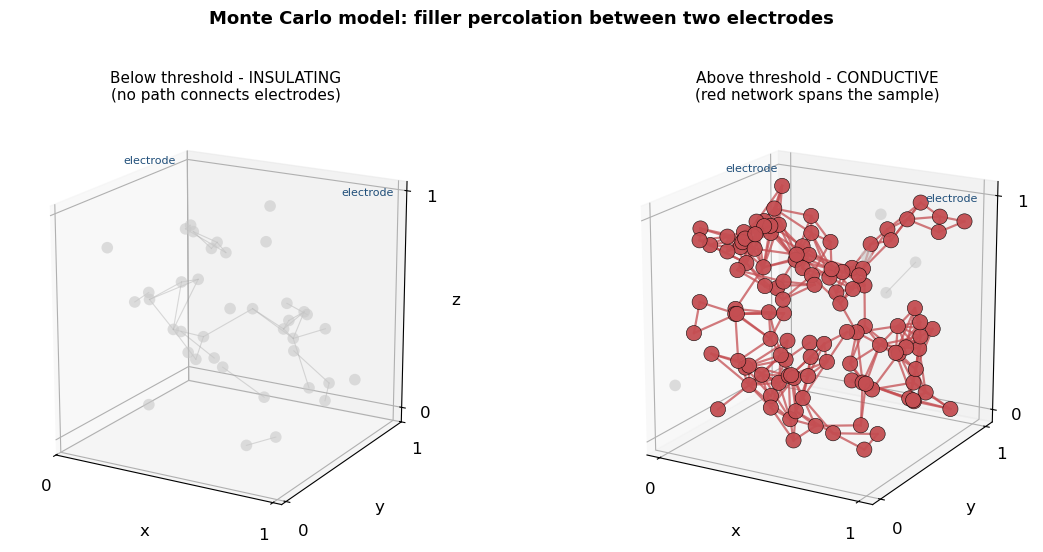

In \[3\]:

    rng = np.random.default_rng(42)
    phi = np.linspace(0.01, 0.20, 20)
    P = np.array([perc_prob_3d(x, r=0.04, k=2.0, trials=150, rng=rng)
                  for x in phi])
    err = np.sqrt(P * (1 - P) / 150)
    pc = threshold(phi, P)
    print("[Fig 2] threshold ~ %.0f vol%%" % (pc * 100))

    plt.figure(figsize=(7, 5))
    plt.errorbar(phi * 100, P, yerr=err, fmt="o-",
                 color="#1f4e79", capsize=3,
                 label="Simulation (3D) +/- SE")
    plt.axvline(pc * 100, ls="--", color="gray",
                label="threshold ~ %.0f vol%%" % (pc * 100))
    plt.xlabel("Filler volume fraction (%)")
    plt.ylabel("Percolation probability P")
    plt.title("The model produces a sharp percolation threshold")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("fig2_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    [Fig 2] threshold ~ 6 vol%

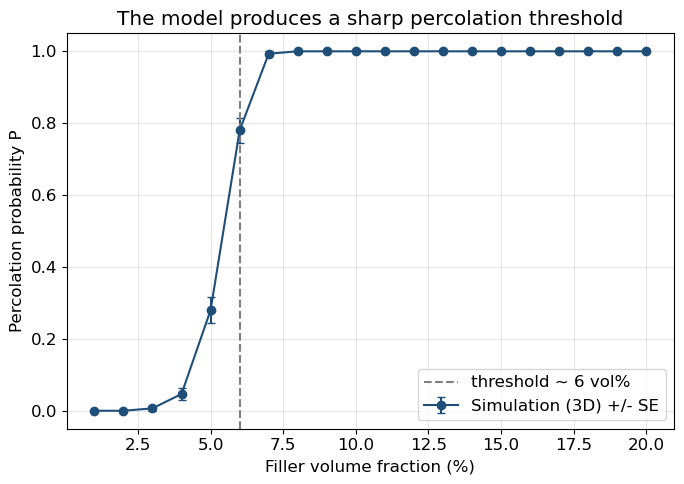

In \[4\]:

    ctab = np.array([85, 115, 138])
    surf_v = phr_to_vol(np.array([33, 28, 26])) * 100
    surf_lbl = ["N347", "N234", "N134"]
    dbp = np.array([124, 154])
    str_v = phr_to_vol(np.array([33, 28])) * 100
    str_lbl = ["N347", "N356"]

    ks = np.array([1.5, 2.0, 2.5, 3.0])
    phi_k = np.linspace(0.01, 0.30, 18)
    k_v = []
    for kk in ks:
        rng = np.random.default_rng(1)
        Pk = np.array([perc_prob_3d(x, r=0.04, k=kk, trials=60, rng=rng)
                       for x in phi_k])
        k_v.append(thr_vol(phi_k, Pk))
    k_v = np.array(k_v)
    print("[Fig 3] k ->", np.round(k_v, 1).tolist())

    asp = np.array([1, 10, 20, 30])
    asp_v = []
    rng = np.random.default_rng(1)
    phis = np.linspace(0.18, 0.45, 8)
    Ps = np.array([perc_prob_3d(x, r=0.03, k=1.0, trials=20, rng=rng)
                   for x in phis])
    asp_v.append(thr_vol(phis, Ps))
    for a in asp[1:]:
        rng = np.random.default_rng(1)
        phir = np.linspace(0.004, 0.08, 9)
        Pr = np.array([rod_prob(x, a * 0.016, 0.008, trials=14, rng=rng)
                       for x in phir])
        asp_v.append(thr_vol(phir, Pr))
    asp_v = np.array(asp_v)
    print("[Fig 3] aspect ->", np.round(asp_v, 1).tolist())

    EXP = "#1f4e79"
    MOD = "#C44E52"
    fig, ax = plt.subplots(2, 2, figsize=(11, 8))

    a = ax[0, 0]
    a.plot(ctab, surf_v, "o-", color=EXP, ms=9)
    for x, y, l in zip(ctab, surf_v, surf_lbl):
        a.annotate(l, (x, y), textcoords="offset points",
                   xytext=(6, 6), fontsize=9)
    a.set_xlabel("Specific surface  CTAB (m$^2$/g)")
    a.set_ylabel("Percolation threshold (vol%)")
    a.set_title("EXPERIMENT - specific surface",
                color=EXP, fontweight="bold")
    a.annotate("higher surface\nlower threshold", (0.5, 0.72),
               xycoords="axes fraction", fontsize=9, color="gray")

    b = ax[0, 1]
    b.plot(dbp, str_v, "s-", color=EXP, ms=9)
    for x, y, l in zip(dbp, str_v, str_lbl):
        b.annotate(l, (x, y), textcoords="offset points",
                   xytext=(6, 6), fontsize=9)
    b.set_xlabel("Structure  DBP (ml/100g)")
    b.set_ylabel("Percolation threshold (vol%)")
    b.set_title("EXPERIMENT - structure",
                color=EXP, fontweight="bold")
    b.annotate("higher structure\nlower threshold", (0.45, 0.72),
               xycoords="axes fraction", fontsize=9, color="gray")

    c = ax[1, 0]
    c.plot(ks, k_v, "o-", color=MOD, ms=9)
    c.set_xlabel("Model tunnelling factor  k")
    c.set_ylabel("Percolation threshold (vol%)")
    c.set_title("MODEL - tunnelling range",
                color=MOD, fontweight="bold")
    c.annotate("stronger tunnelling\nlower threshold", (0.42, 0.68),
               xycoords="axes fraction", fontsize=9, color="gray")

    e = ax[1, 1]
    e.plot(asp, asp_v, "s-", color=MOD, ms=9)
    e.set_xlabel("Model aspect ratio  (1 = sphere)")
    e.set_ylabel("Percolation threshold (vol%)")
    e.set_title("MODEL - aspect ratio / shape",
                color=MOD, fontweight="bold")
    e.annotate("higher aspect ratio\nlower threshold", (0.4, 0.6),
               xycoords="axes fraction", fontsize=9, color="gray")

    for axx in ax.ravel():
        axx.grid(alpha=0.3)
    fig.suptitle("Threshold falls with filler connectivity - "
                 "experiment and model agree in DIRECTION",
                 fontsize=13, fontweight="bold", y=0.99)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig("fig3_trend.png", dpi=300, bbox_inches="tight")
    plt.show()

    [Fig 3] k -> [12.9, 6.1, 4.4, 2.7]
    [Fig 3] aspect -> [37.3, 7.0, 4.2, 3.2]

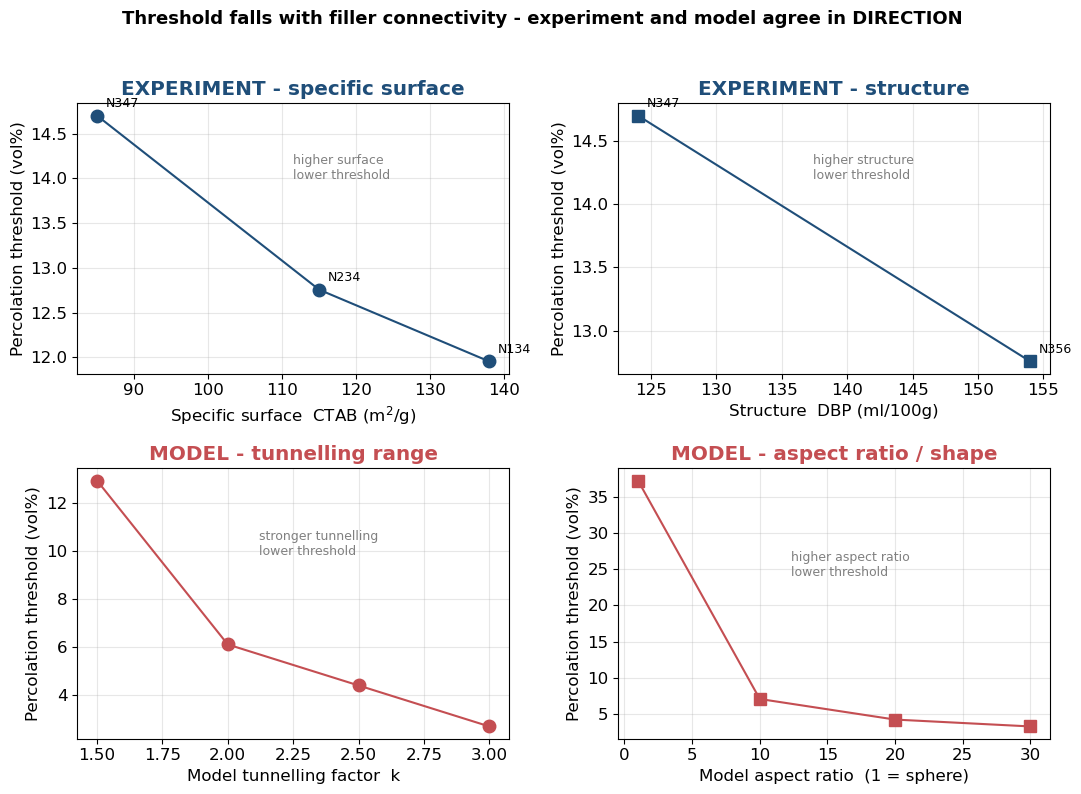

In \[5\]:

    epdm_phr = np.array([20, 40, 60, 75, 80, 85, 90,
                         95, 100, 105, 110, 120])
    epdm_log = np.array([15.7, 15.4, 9.8, 5.8, 4.1, 4.3,
                         3.3, 2.9, 2.5, 2.3, 2.15, 2.1])
    epdm_vol = phr_to_vol(epdm_phr, rho_m=0.86) * 100

    rng = np.random.default_rng(42)
    r = 0.05
    gap = 0.32
    phi = np.concatenate([np.linspace(0.02, 0.12, 5),
                          np.linspace(0.13, 0.34, 28),
                          np.linspace(0.36, 0.44, 4)])
    Srel = np.array([np.mean([eff_cond(x, r, gap=gap, rng=rng)
                              for _ in range(80)]) for x in phi])
    Smono = np.maximum.accumulate(Srel)
    SIG_SAT = 1e-2
    SIG_MAT = 10 ** -15.5
    rho = 1.0 / (SIG_SAT * Smono / Smono.max() + SIG_MAT)
    sim_vol = phi * 100.0
    on = sim_vol[np.argmax(Smono > 1e-6)]
    print("[Fig 4] sim onset ~ %.0f vol%%" % on)

    plt.figure(figsize=(7.4, 5.4))
    plt.axhline(15.5, ls=":", color="gray", alpha=0.6)
    plt.axhline(2.0, ls=":", color="gray", alpha=0.6)
    plt.text(0.5, 15.9, "unfilled (insulating)",
             fontsize=8, color="gray")
    plt.text(23, 1.3, "percolated (conductive)",
             fontsize=8, color="gray")
    plt.scatter(epdm_vol, epdm_log, s=60, color="blue", zorder=3,
                label="Experiment - EPDM + CB\n(Herrmann/Degussa 2005)")
    plt.plot(sim_vol, np.log10(rho), "-", color="#C44E52",
             lw=2.4, label="Simulation (this work)")
    plt.xlabel("Filler volume fraction (%)")
    plt.ylabel("log10(volume resistivity / Ohm.cm)")
    plt.title("Percolation transition: simulation vs experiment")
    plt.ylim(0, 17.5)
    plt.xlim(0, 40)
    plt.legend(fontsize=9, loc="lower left")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("fig4_exp_vs_sim.png", dpi=300, bbox_inches="tight")
    plt.show()

    [Fig 4] sim onset ~ 16 vol%

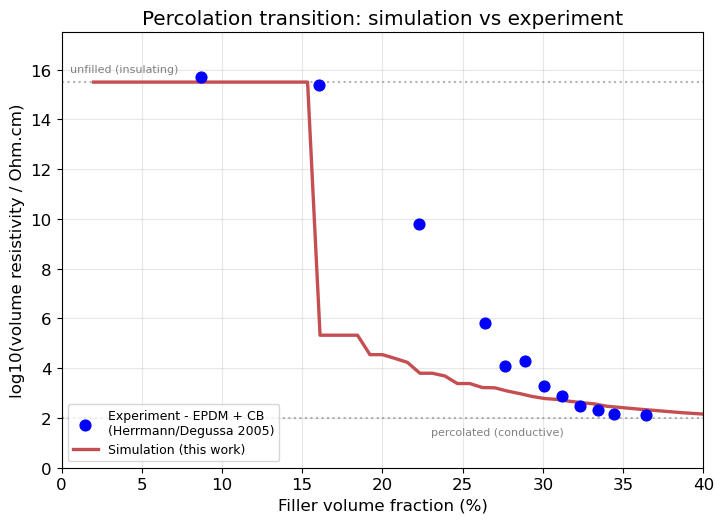

In \[ \]: